In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome

Nombre total d'images : 7796

Répartition des labels :
label
glaucome    1949
mda         1949
diabete     1949
normaux     1949
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 7016
Test : 780

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [4]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    """
    img: numpy array BGR ou grayscale
    thr: seuil (0-255)
    pad: marge ajoutée autour du crop
    """
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

# Fonction pour charger et prétraiter une image
def load_image(path, size=(128, 128)):
    """Charge une image, enlève les bords noirs et redimensionne"""
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    """Génère des versions augmentées (rotation, flip, luminosité)."""
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))
    aug.append(cv2.flip(img, 0))
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))
    return aug  # 5 variantes

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [5]:
from skimage.feature import hog

def extract_hog_features(img):
    """Extrait les features HOG d'une image BGR"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features.astype(np.float32)

def extract_pixel_features(img):
    """Extrait les pixels aplatis (pour PCA)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [6]:
# Extraire les features de toutes les images
def extract_all_features(df_subset, extract_func, augment=False):
    """Extrait les features pour un dataframe donné"""
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        feat = extract_func(img)
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)

        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}  (x6 avec augmentation)")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


  0%|          | 5/7016 [00:00<06:48, 17.17it/s][ WARN:0@23.443] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@23.443] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 161/7016 [00:08<04:45, 23.99it/s][ WARN:0@31.340] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@31.340] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 454/7016 [00:21<05:10, 21.10it/s][ WARN:0@44.584] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@44.584] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 801/7016 [00:37<04:51, 21.29it/s][ WARN:0@60.707] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirect


Shape X_train_pixels: (42096, 16384)  (x6 avec augmentation)
Shape X_test_pixels: (780, 16384)


In [7]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

print(f"\nShape X_train_hog: {X_train_hog.shape}  (x6 avec augmentation)")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


  0%|          | 6/7016 [00:00<07:17, 16.03it/s][ WARN:0@380.063] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@380.063] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 160/7016 [00:11<07:48, 14.62it/s][ WARN:0@391.565] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@391.565] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 455/7016 [00:32<07:18, 14.95it/s][ WARN:0@412.128] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@412.128] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 801/7016 [00:57<06:58, 14.84it/s][ WARN:0@436.802] global grfmt_tiff.cpp:122 TIFF_Warning TIFFRea


Shape X_train_hog: (42096, 8100)  (x6 avec augmentation)
Shape X_test_hog: (780, 8100)


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardiser les pixels (PCA sera appliquée dans le Pipeline GridSearch)
scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels).astype(np.float32)
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels).astype(np.float32)
del X_train_pixels, X_test_pixels  # libere ~2.3 GB

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}")
print("PCA sera testée avec différents n_components dans le GridSearch")

Shape X_train_pixels_scaled: (42096, 16384)
PCA sera testée avec différents n_components dans le GridSearch


In [9]:
# Standardiser HOG
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog).astype(np.float32)
X_test_hog_scaled  = scaler_hog.transform(X_test_hog).astype(np.float32)
del X_train_hog, X_test_hog  # libere ~1 GB

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features   = X_train_hog_scaled.shape[1]

print(f"X_train_pixels_scaled : {X_train_pixels_scaled.shape}  float32")
print(f"X_train_hog_scaled    : {X_train_hog_scaled.shape}  float32")

X_train_pixels_scaled : (42096, 16384)  float32
X_train_hog_scaled    : (42096, 8100)  float32


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

rf_params = {
    'n_estimators':      [20, 100, 200, 300],
    'max_depth':         [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf':  [1, 2, 4, 7],
    'max_features':      ['sqrt', 'log2']
}

pca_components = [30, 50, 75, 100, 125, 150]

cv_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

results = {}

print("Paramètres RF à tester:")
for key, values in rf_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester: {pca_components}")


Paramètres RF à tester:
  n_estimators: [20, 100, 200, 300]
  max_depth: [10, 20, 30, 40, None]
  min_samples_split: [2, 5, 7, 10]
  min_samples_leaf: [1, 2, 4, 7]
  max_features: ['sqrt', 'log2']

Composantes PCA à tester: [30, 50, 75, 100, 125, 150]


RandomizedSearch pour: PCA
Fitting 1 folds for each of 300 candidates, totalling 300 fits

Meilleurs paramètres: {'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 30, 'pca__n_components': 30}
Meilleur score val: 0.8564

 Métrique                 Score
--------------------------------
 Test Accuracy           0.8000
 Balanced Acc            0.8000
 Precision               0.7987
 Recall                  0.8000
 F1 Score                0.7832


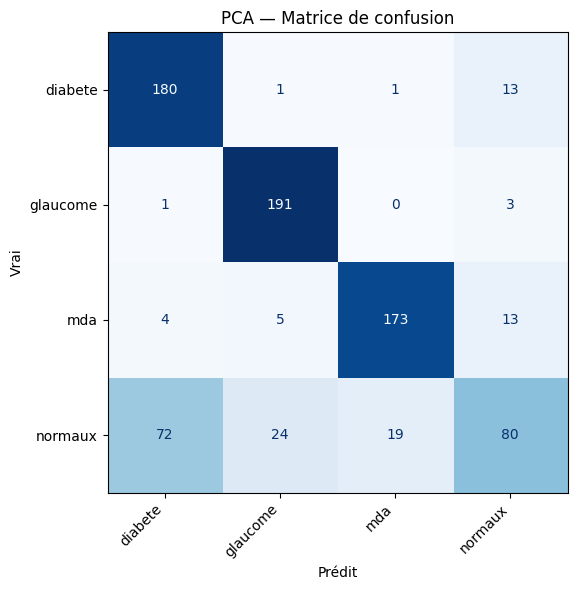

In [11]:
results = {}

print("="*60)
print("RandomizedSearch pour: PCA")
print("="*60)

pipe_pca = Pipeline([
    ('pca', PCA(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])
param_grid_pca = {
    'pca__n_components': pca_components,
    **{f'rf__{k}': v for k, v in rf_params.items()}
}
grid_pca = RandomizedSearchCV(pipe_pca, param_grid_pca, n_iter=300, cv=cv_split,
    scoring='accuracy', n_jobs=1, verbose=1, random_state=42)
grid_pca.fit(X_train_pixels_scaled, y_train)
print(f'\nMeilleurs paramètres: {grid_pca.best_params_}')
print(f'Meilleur score val: {grid_pca.best_score_:.4f}')
results['PCA'] = {'best_model': grid_pca.best_estimator_, 'best_params': grid_pca.best_params_,
    'best_val_score': grid_pca.best_score_, 'X_test': X_test_pixels_scaled}

# --- Résultats test ---
_y_pred = grid_pca.best_estimator_.predict(X_test_pixels_scaled)
_acc  = accuracy_score(y_test, _y_pred)
_bacc = balanced_accuracy_score(y_test, _y_pred)
_prec = precision_score(y_test, _y_pred, average='macro', zero_division=0)
_rec  = recall_score(y_test, _y_pred, average='macro', zero_division=0)
_f1   = f1_score(y_test, _y_pred, average='macro', zero_division=0)
print(f"\n{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {_acc:>8.4f}")
print(f"{' Balanced Acc':<22} {_bacc:>8.4f}")
print(f"{' Precision':<22} {_prec:>8.4f}")
print(f"{' Recall':<22} {_rec:>8.4f}")
print(f"{' F1 Score':<22} {_f1:>8.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, _y_pred, labels=list(range(len(classes)))), display_labels=classes).plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title("PCA — Matrice de confusion"); ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()
results['PCA']['y_pred'] = _y_pred
results['PCA']['test_accuracy'] = _acc
results['PCA']['test_balanced_accuracy'] = _bacc
results['PCA']['test_f1'] = _f1

RandomizedSearch pour: HOG
Fitting 1 folds for each of 300 candidates, totalling 300 fits

Meilleurs paramètres: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Meilleur score val: 0.8093

 Métrique                 Score
--------------------------------
 Test Accuracy           0.7872
 Balanced Acc            0.7872
 Precision               0.7936
 Recall                  0.7872
 F1 Score                0.7585


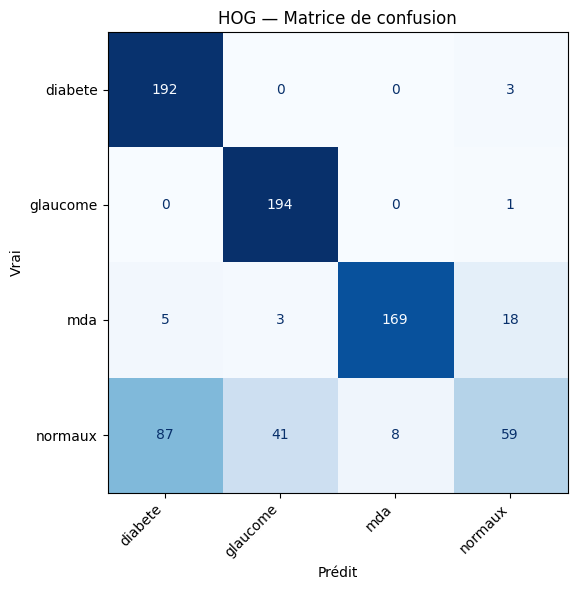

In [11]:
print("="*60)
print("RandomizedSearch pour: HOG")
print("="*60)

rf_hog = RandomForestClassifier(random_state=42)
grid_hog = RandomizedSearchCV(rf_hog, rf_params, n_iter=300, cv=cv_split,
    scoring='accuracy', n_jobs=1, verbose=1, random_state=42)
grid_hog.fit(X_train_hog_scaled, y_train)
print(f'\nMeilleurs paramètres: {grid_hog.best_params_}')
print(f'Meilleur score val: {grid_hog.best_score_:.4f}')
results['HOG'] = {'best_model': grid_hog.best_estimator_, 'best_params': grid_hog.best_params_,
    'best_val_score': grid_hog.best_score_, 'X_test': X_test_hog_scaled}

# --- Résultats test ---
_y_pred = grid_hog.best_estimator_.predict(X_test_hog_scaled)
_acc  = accuracy_score(y_test, _y_pred)
_bacc = balanced_accuracy_score(y_test, _y_pred)
_prec = precision_score(y_test, _y_pred, average='macro', zero_division=0)
_rec  = recall_score(y_test, _y_pred, average='macro', zero_division=0)
_f1   = f1_score(y_test, _y_pred, average='macro', zero_division=0)
print(f"\n{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {_acc:>8.4f}")
print(f"{' Balanced Acc':<22} {_bacc:>8.4f}")
print(f"{' Precision':<22} {_prec:>8.4f}")
print(f"{' Recall':<22} {_rec:>8.4f}")
print(f"{' F1 Score':<22} {_f1:>8.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, _y_pred, labels=list(range(len(classes)))), display_labels=classes).plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title("HOG — Matrice de confusion"); ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()
results['HOG']['y_pred'] = _y_pred
results['HOG']['test_accuracy'] = _acc
results['HOG']['test_balanced_accuracy'] = _bacc
results['HOG']['test_f1'] = _f1

RandomizedSearch pour: PCA + HOG
X_train_combined_raw: (42096, 24484)  (4.12 GB)
Fitting 1 folds for each of 300 candidates, totalling 300 fits

Meilleurs paramètres: {'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 30, 'features__pca__n_components': 100}
Meilleur score val: 0.8121

 Métrique                 Score
--------------------------------
 Test Accuracy           0.7846
 Balanced Acc            0.7846
 Precision               0.7910
 Recall                  0.7846
 F1 Score                0.7565


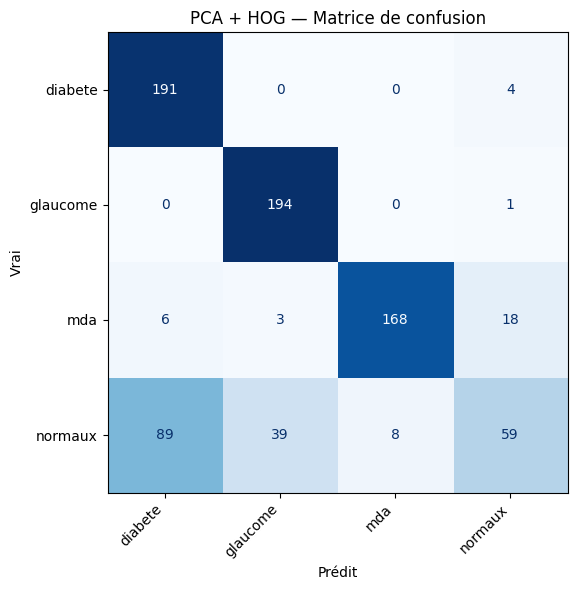

In [10]:
print("="*60)
print("RandomizedSearch pour: PCA + HOG")
print("="*60)

pixel_cols = list(range(n_pixel_features))
hog_cols   = list(range(n_pixel_features, n_pixel_features + n_hog_features))
X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw  = np.hstack([X_test_pixels_scaled,  X_test_hog_scaled])
print(f"X_train_combined_raw: {X_train_combined_raw.shape}  ({X_train_combined_raw.nbytes/1e9:.2f} GB)")

pipe_combined = Pipeline([
    ('features', ColumnTransformer([
        ('pca', PCA(random_state=42), pixel_cols),
        ('hog', 'passthrough',        hog_cols)
    ])),
    ('rf', RandomForestClassifier(random_state=42))
])
param_grid_combined = {
    'features__pca__n_components': pca_components,
    **{f'rf__{k}': v for k, v in rf_params.items()}
}
grid_combined = RandomizedSearchCV(pipe_combined, param_grid_combined, n_iter=300, cv=cv_split,
    scoring='accuracy', n_jobs=1, verbose=1, random_state=42)
grid_combined.fit(X_train_combined_raw, y_train)
del X_train_combined_raw
print(f'\nMeilleurs paramètres: {grid_combined.best_params_}')
print(f'Meilleur score val: {grid_combined.best_score_:.4f}')
results['PCA + HOG'] = {'best_model': grid_combined.best_estimator_, 'best_params': grid_combined.best_params_,
    'best_val_score': grid_combined.best_score_, 'X_test': X_test_combined_raw}

# --- Résultats test ---
_y_pred = grid_combined.best_estimator_.predict(X_test_combined_raw)
_acc  = accuracy_score(y_test, _y_pred)
_bacc = balanced_accuracy_score(y_test, _y_pred)
_prec = precision_score(y_test, _y_pred, average='macro', zero_division=0)
_rec  = recall_score(y_test, _y_pred, average='macro', zero_division=0)
_f1   = f1_score(y_test, _y_pred, average='macro', zero_division=0)
print(f"\n{' Métrique':<22} {'Score':>8}")
print(f"{'-'*32}")
print(f"{' Test Accuracy':<22} {_acc:>8.4f}")
print(f"{' Balanced Acc':<22} {_bacc:>8.4f}")
print(f"{' Precision':<22} {_prec:>8.4f}")
print(f"{' Recall':<22} {_rec:>8.4f}")
print(f"{' F1 Score':<22} {_f1:>8.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, _y_pred, labels=list(range(len(classes)))), display_labels=classes).plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
ax.set_title("PCA + HOG — Matrice de confusion"); ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()
results['PCA + HOG']['y_pred'] = _y_pred
results['PCA + HOG']['test_accuracy'] = _acc
results['PCA + HOG']['test_balanced_accuracy'] = _bacc
results['PCA + HOG']['test_f1'] = _f1

Entraînement du meilleur modèle PCA + HOG...
Entraînement terminé ✓


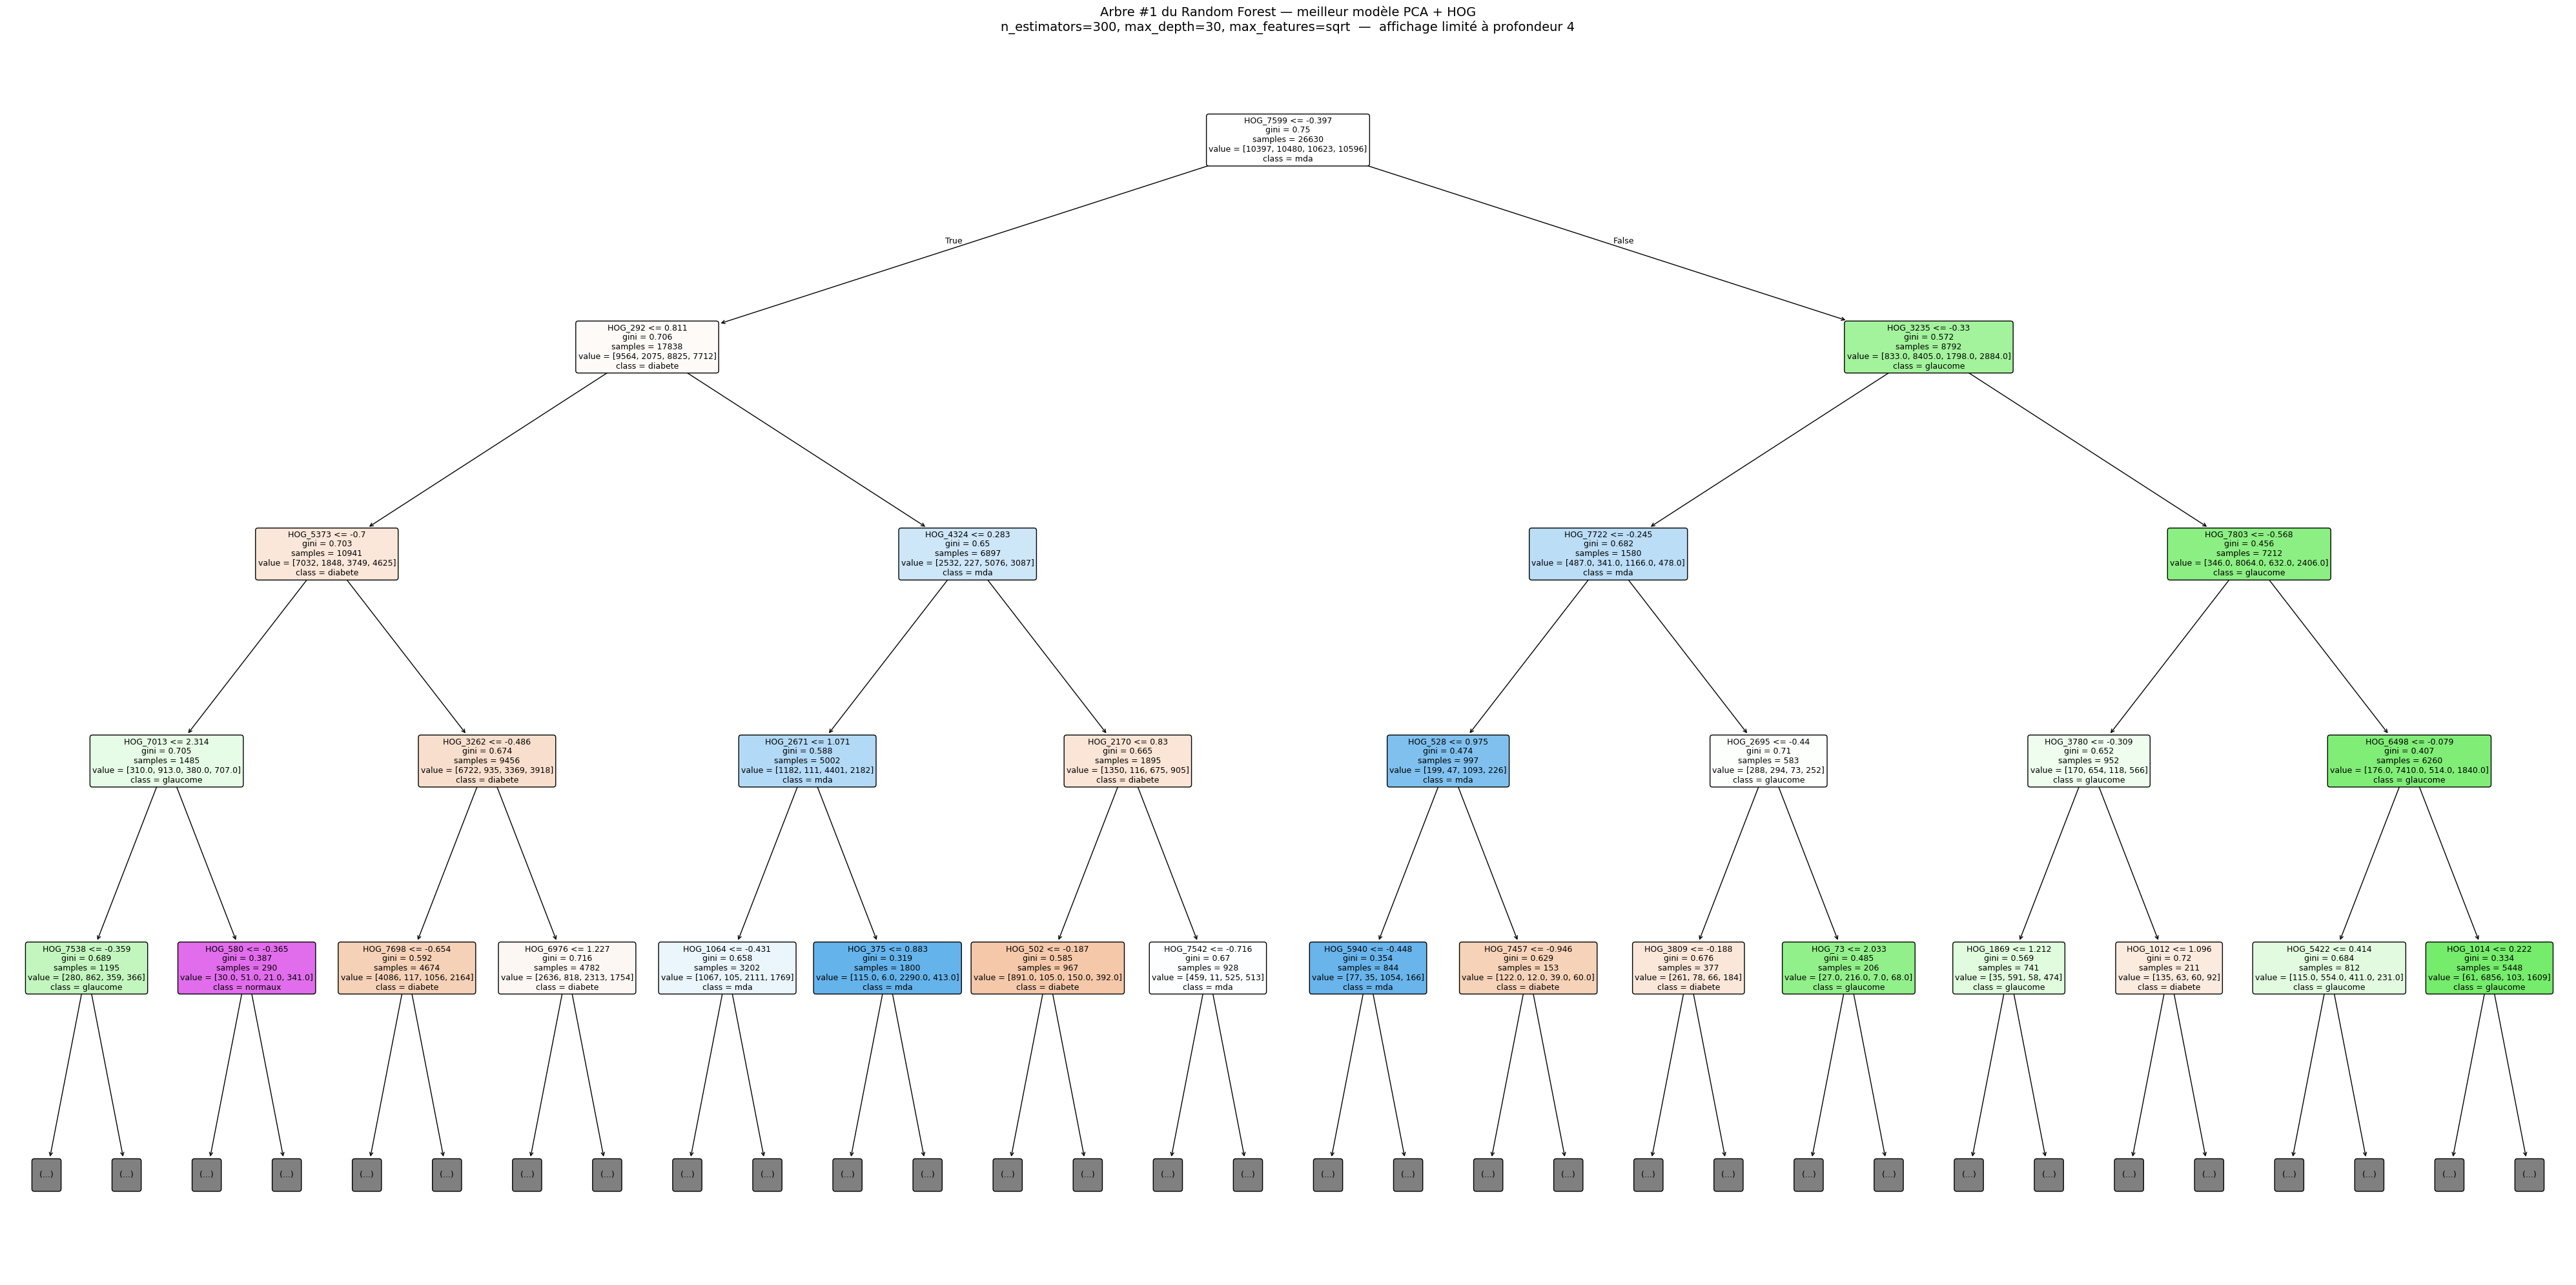

In [14]:
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Meilleurs paramètres connus (PCA + HOG)
BEST_PCA_N = 100
BEST_RF_PARAMS = dict(
    n_estimators=300,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# Reconstruire le pipeline directement avec les meilleurs paramètres
pixel_cols = list(range(X_train_pixels_scaled.shape[1]))
hog_cols   = list(range(X_train_pixels_scaled.shape[1],
                        X_train_pixels_scaled.shape[1] + X_train_hog_scaled.shape[1]))

best_pipe = Pipeline([
    ('features', ColumnTransformer([
        ('pca', PCA(n_components=BEST_PCA_N, random_state=42), pixel_cols),
        ('hog', 'passthrough', hog_cols)
    ])),
    ('rf', RandomForestClassifier(**BEST_RF_PARAMS))
])
X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw  = np.hstack([X_test_pixels_scaled,  X_test_hog_scaled])
print("Entraînement du meilleur modèle PCA + HOG...")
best_pipe.fit(X_train_combined_raw, y_train)
print("Entraînement terminé ✓")

# Noms des features
feature_names = (
    [f'PCA_{i}' for i in range(BEST_PCA_N)] +
    [f'HOG_{i}' for i in range(X_train_hog_scaled.shape[1])]
)

# Visualiser l'arbre #1 (profondeur limitée à 4 pour la lisibilité)
classes = ['diabete', 'glaucome', 'mda', 'normaux']
tree_to_plot = best_pipe.named_steps['rf'].estimators_[0]

fig, ax = plt.subplots(figsize=(40, 20))
plot_tree(
    tree_to_plot,
    max_depth=4,
    feature_names=feature_names,
    class_names=classes,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    "Arbre #1 du Random Forest — meilleur modèle PCA + HOG\n"
    f"n_estimators=300, max_depth=30, max_features=sqrt  —  affichage limité à profondeur 4",
    fontsize=14
)
plt.tight_layout()
plt.show()